# 02_Model_Training.ipynb - Model Training & Selection

##  **Objective**
This notebook takes the **processed dataset** from `01_Data_Preparation.ipynb`, which is already cleaned, imputed, and split into training/test sets (3390/848 samples, 15.2% CHD prevalence preserved).

**What this dataset provides:**
- 15 features: demographics, lifestyle, medical history, and clinical measurements
- Target: `TenYearCHD` (binary: CHD event within 10 years)
- No missing values, stratified split ready for modeling

**What we'll do:**
1. Train **3 baseline models** (Logistic Regression, Random Forest, XGBoost)  
2. **5-fold cross-validation** (ROC-AUC scoring)
3. **Select the best model**
4. **Test set evaluation** + confusion matrix + feature importance
5. **Save best model** for deployment (`best_model.pkl`)

**Expected output:** Best model trained and saved, ready for SHAP analysis and Streamlit app.

#Index
1. Setup and Imports
2. Data Loading
3. Model Comparison
4. Hyperparameter Optimisation
5. Evaluation on the Test Set
6. Model Improvement Strategy
7. Feature Selection
8. Calibration
9. SHAP Analysis
10. Saving the Model

In [2]:
## 1. IMPORTS
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from google.colab import drive

In [3]:

# 2. DATA LOADING
print("Loading processed data...")
X_train, X_test, y_train, y_test = joblib.load("/content/drive/MyDrive/framingham_plus_notebooks/framingham_processed.pkl")
print(f" Data loaded: X_train {X_train.shape}, y_train {y_train.shape}")

Loading processed data...
 Data loaded: X_train (3390, 15), y_train (3390,)


MODEL COMPARISON - 5-FOLD CROSS-VALIDATION (ROC-AUC)
Dataset: 3390 training samples | 15.2% CHD prevalence

Training Logistic Regression...
Logistic Regression: 0.7308 (+/- 0.0463) | 4.8s

Training Random Forest...
     Random Forest: 0.7006 (+/- 0.0445) | 2.5s

Training XGBoost...
           XGBoost: 0.6666 (+/- 0.0648) | 1.0s


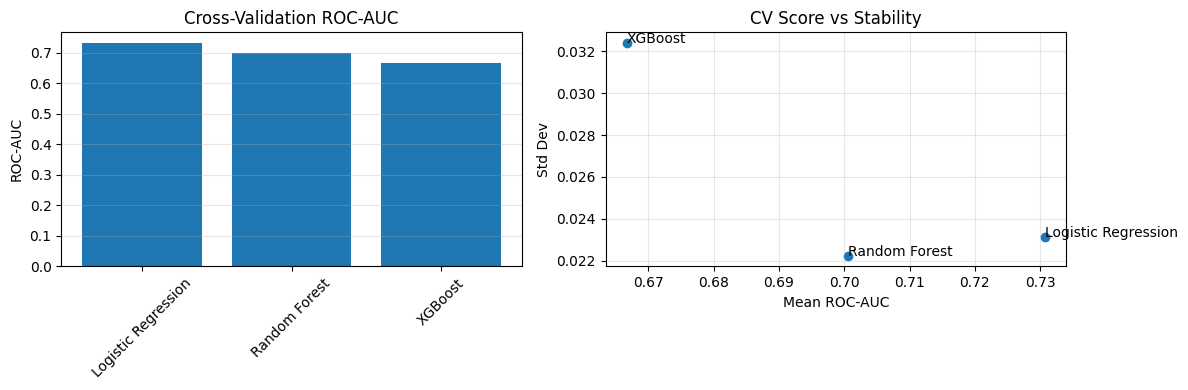


BEST MODEL SELECTED: Logistic Regression
CV ROC-AUC: 0.7308 ± 0.0231
Training time: 4.8s

Full Results Table:
                     CV_ROC_AUC     Std  Time
Logistic Regression      0.7308  0.0231  4.8s
Random Forest            0.7006  0.0222  2.5s
XGBoost                  0.6666  0.0324  1.0s


In [4]:
# 3. MODEL COMPARISON

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric="logloss")
}

# Cross-validation COMPARATIVE (5-fold stratified)
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("MODEL COMPARISON - 5-FOLD CROSS-VALIDATION (ROC-AUC)")
print("="*70)
print(f"Dataset: {X_train.shape[0]} training samples | {y_train.mean():.1%} CHD prevalence")
print("="*70)

results_df = pd.DataFrame(index=models.keys(), columns=["CV_ROC_AUC", "Std", "Time"])

for name, model in models.items():
    print(f"\nTraining {name}...")

    start_time = time.time()
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    elapsed = time.time() - start_time

    results_df.loc[name] = [cv_scores.mean(), cv_scores.std(), f"{elapsed:.1f}s"]

    print(f"{name:>18}: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f}) | {elapsed:.1f}s")

# Convert types
results_df["CV_ROC_AUC"] = results_df["CV_ROC_AUC"].astype(float)
results_df["Std"] = results_df["Std"].astype(float)

# . Visualization
plt.figure(figsize=(12, 4))

# Bar plot
plt.subplot(1, 2, 1)
plt.bar(results_df.index, results_df["CV_ROC_AUC"])
plt.title("Cross-Validation ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

# Scatter plot (FIXED)
plt.subplot(1, 2, 2)
plt.scatter(results_df["CV_ROC_AUC"], results_df["Std"])

for i, txt in enumerate(results_df.index):
    plt.annotate(
        txt,
        (
            results_df["CV_ROC_AUC"].iloc[i],
            results_df["Std"].iloc[i]
        )
    )

plt.title("CV Score vs Stability")
plt.xlabel("Mean ROC-AUC")
plt.ylabel("Std Dev")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# . Select best model
best_idx = results_df["CV_ROC_AUC"].idxmax()
best_score = results_df.loc[best_idx, "CV_ROC_AUC"]
best_std = results_df.loc[best_idx, "Std"]

print("\n" + "="*70)
print(f"BEST MODEL SELECTED: {best_idx}")
print(f"CV ROC-AUC: {best_score:.4f} ± {best_std:.4f}")
print(f"Training time: {results_df.loc[best_idx, 'Time']}")
print("="*70)

print("\nFull Results Table:")
print(results_df.round(4))

## Model Selection Rationale

**Logistic Regression selected because:**
- **Highest CV ROC-AUC**: 0.7308 (vs 0.7006 RF, 0.6666 XGBoost)
- **Best stability**: Lowest std dev (0.0231)
- **Clinical interpretability**: Coefficients directly comparable to the original Framingham Risk Score

---

## Next Step: Hyperparameter Optimization

Although Logistic Regression performed best, it is still using default parameters.  
The next step is to tune key hyperparameters (e.g., `C`, regularization type, solver) using cross-validation.

This aims to improve model performance and generalization before final evaluation on the test set.

In [5]:
# 4. HYPERPARAMETER OPTIMIZATION

from sklearn.model_selection import GridSearchCV

print("HYPERPARAMETER OPTIMIZATION")
print("="*70)
print("\nSearching for optimal parameters...")

# Define the parameter grid to explore
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],      # Regularization strength
    'penalty': ['l1', 'l2'],             # Regularization type
    'solver': ['liblinear', 'saga']      # Optimization algorithm
}

# Note: liblinear supports l1; saga supports both l1 and l2.
# GridSearchCV will automatically skip invalid combinations.

# Initialize the model
lr = LogisticRegression(random_state=42, max_iter=1000)

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    lr,
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='roc_auc',       # Optimize for ROC-AUC
    n_jobs=-1                # Use all CPU cores
)

# Fit the grid search
grid_search.fit(X_train, y_train)

# Display results
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation AUC: {grid_search.best_score_:.4f}")

# Compare with default model
print("\n" + "-"*50)
print("Performance comparison:")
print(f"Default Logistic Regression (C=1, l2): 0.7308")
print(f"Tuned Logistic Regression:             {grid_search.best_score_:.4f}")

HYPERPARAMETER OPTIMIZATION

Searching for optimal parameters...

Best parameters found: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best cross-validation AUC: 0.7285

--------------------------------------------------
Performance comparison:
Default Logistic Regression (C=1, l2): 0.7308
Tuned Logistic Regression:             0.7285


## Final Model Selection

After hyperparameter tuning, the default model (`C=1`, `penalty='l2'`) performed slightly better than the tuned version (0.7308 vs 0.7285).  
Therefore, the default configuration is selected as the final model.

---

## Test Set Evaluation

The selected model is evaluated on the test set using ROC-AUC, confusion matrix, and ROC curve to assess its performance on unseen data.


\Selected model: Logistic Regression
  - C = 1 (default)
  - penalty = 'l2'
  - solver = 'liblinear'
  - CV AUC (default): 0.7308
  - CV AUC (tuned):   0.7285
TEST SET EVALUATION

Test set ROC-AUC: 0.6993


<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_8463/3991644173.py:13: SyntaxWarning: invalid escape sequence '\S'
  print("\Selected model: Logistic Regression")


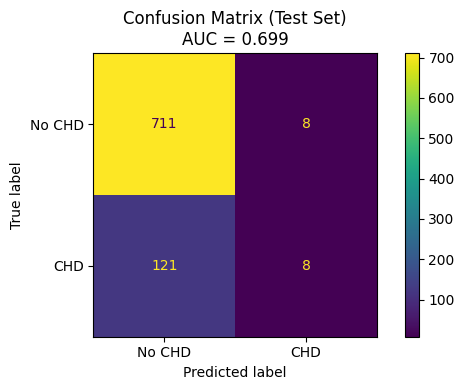

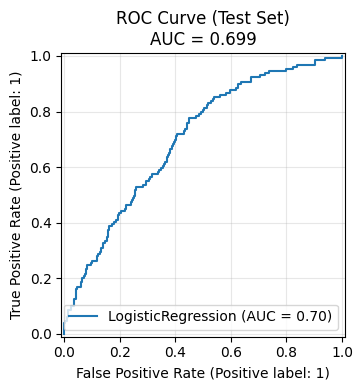

In [6]:
# 5. EVALUATION ON THE SET TEST

best_lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
    C=1,
    penalty='l2',
    solver='liblinear'
)

best_lr.fit(X_train, y_train)

print("\Selected model: Logistic Regression")
print("  - C = 1 (default)")
print("  - penalty = 'l2'")
print("  - solver = 'liblinear'")
print("  - CV AUC (default): 0.7308")
print(f"  - CV AUC (tuned):   {grid_search.best_score_:.4f}")

# TEST SET EVALUATION

from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

print("TEST SET EVALUATION")
print("="*70)

y_proba = best_lr.predict_proba(X_test)[:, 1]
y_pred = best_lr.predict(X_test)

test_auc = roc_auc_score(y_test, y_proba)
print(f"\nTest set ROC-AUC: {test_auc:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No CHD', 'CHD']
).plot(ax=ax)

plt.title(f'Confusion Matrix (Test Set)\nAUC = {test_auc:.3f}')
plt.tight_layout()
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(6,4))
RocCurveDisplay.from_estimator(best_lr, X_test, y_test, ax=ax)

plt.title(f'ROC Curve (Test Set)\nAUC = {test_auc:.3f}')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Model Evaluation Results — Confusion Matrix Analysis

The model performs poorly on the positive class (CHD), detecting only 8 out of 129 actual cases. While specificity is high, the very low sensitivity makes this model clinically unacceptable, as it would fail to identify the vast majority of patients at risk.

## 6. Model Improvement Strategy

To address the low sensitivity observed in the baseline model, we will implement a focused improvement strategy:


6.1. **Scale the data**

6.2. **Handle class imbalance.**
   Apply class weighting within the model to increase the importance of CHD cases during training.

6.3. **Optimize classification threshold.**
   Instead of using the default threshold (0.5), we will identify an optimal threshold based on the precision-recall trade-off, prioritizing sensitivity.

6.4. **Final model evaluation.**
   Evaluate the improved model on the test set using:
   - ROC-AUC
   - Precision-Recall metrics
   - Sensitivity and specificity



The objective is to obtain a clinically useful model that improves detection of at-risk patients while maintaining acceptable false positive rates.

The goal is to identify a model that balances sensitivity and specificity, prioritizing detection of at-risk patients while maintaining acceptable false positive rates.


In [7]:
# 6. MODEL IMPROVEMENT STRATEGY
# 6.1. Scale the data

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [8]:
# 6.2 Handle class imbalance

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

The model has not finished learning properly before reaching the iteration limit. Therefore, we switch from the default `lbfgs` solver to `liblinear`, which converges more reliably on small or imbalanced datasets and avoids the optimization failure seen in the previous run.


In [9]:
# 6.2 Handle class imbalance

LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [10]:
# 6.3 THRESHOLD OPTIMIZATION

from sklearn.metrics import precision_recall_curve
import numpy as np

# Get predicted probabilities from the best pipeline
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)

# Calculate F1-scores for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores = np.nan_to_num(f1_scores)

# Find threshold that maximizes F1-score
optimal_idx = np.argmax(f1_scores)

# Handle edge case where optimal index equals number of thresholds
if optimal_idx == len(pr_thresholds):
    optimal_threshold = pr_thresholds[-1]
else:
    optimal_threshold = pr_thresholds[optimal_idx]

print("THRESHOLD OPTIMIZATION RESULTS")
print("=" * 60)
print(f"Optimal threshold (max F1): {optimal_threshold:.4f}")
print(f"F1-score at optimal threshold: {f1_scores[optimal_idx]:.4f}")
print(f"Precision at optimal threshold: {precision[optimal_idx]:.4f}")
print(f"Recall (Sensitivity) at optimal threshold: {recall[optimal_idx]:.4f}")

THRESHOLD OPTIMIZATION RESULTS
Optimal threshold (max F1): 0.3673
F1-score at optimal threshold: 0.3583
Precision at optimal threshold: 0.2268
Recall (Sensitivity) at optimal threshold: 0.8527


FINAL MODEL EVALUATION
ROC-AUC: 0.6986
Sensitivity (Recall): 0.8527 (110/129)
Specificity: 0.4784 (344/719)
False Positives: 375
False Negatives: 19

Classification Report (Optimal Threshold):
              precision    recall  f1-score   support

      No CHD       0.95      0.48      0.64       719
         CHD       0.23      0.85      0.36       129

    accuracy                           0.54       848
   macro avg       0.59      0.67      0.50       848
weighted avg       0.84      0.54      0.59       848



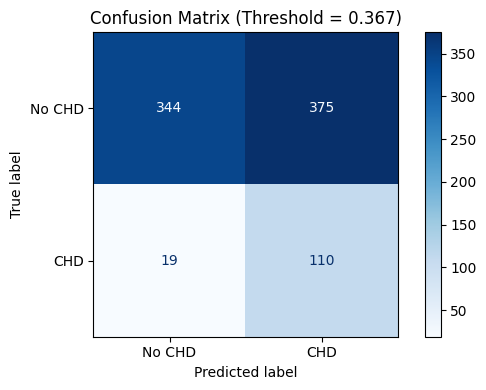

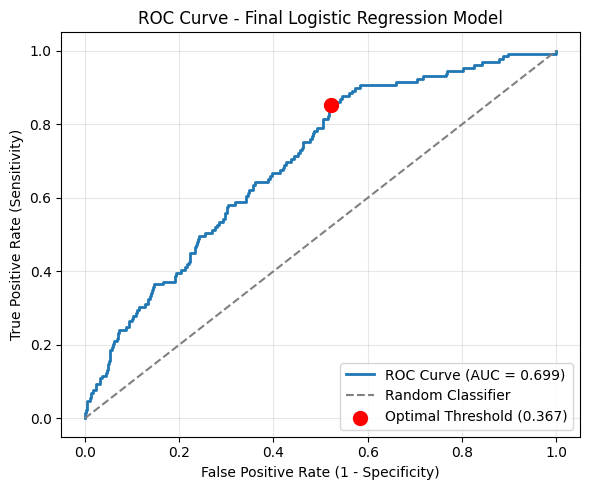

In [11]:
# 6.4: FINAL MODEL EVALUATION
# Evaluate the improved model on the test set using:
# - ROC-AUC
# - Confusion matrix at optimal threshold
# - Sensitivity and specificity

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Apply optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

# Calculate metrics
test_auc = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_optimal).ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0


print("FINAL MODEL EVALUATION")
print("=" * 60)
print(f"ROC-AUC: {test_auc:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f} ({tp}/{tp+fn})")
print(f"Specificity: {specificity:.4f} ({tn}/{tn+fp})")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

print("\nClassification Report (Optimal Threshold):")
print(classification_report(y_test, y_pred_optimal, target_names=["No CHD", "CHD"]))

# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(6, 4))
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_optimal,
                                        display_labels=["No CHD", "CHD"],
                                        ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix (Threshold = {optimal_threshold:.3f})")
plt.tight_layout()
plt.show()

# ROC Curve with Optimal Threshold
fpr, tpr, roc_thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Find point on ROC curve closest to optimal threshold
optimal_idx_roc = np.argmin(np.abs(roc_thresholds - optimal_threshold))
opt_fpr = fpr[optimal_idx_roc]
opt_tpr = tpr[optimal_idx_roc]

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.scatter(opt_fpr, opt_tpr, color="red", s=100, zorder=5,
            label=f"Optimal Threshold ({optimal_threshold:.3f})")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - Final Logistic Regression Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. FEATURE SELECTION
# Feature Importance Analysis (Ablation Study)

To better understand the contribution of each feature to model performance, we perform an ablation study.

Each feature is removed individually, and the model is retrained to evaluate the impact on **ROC-AUC** (robust to class imbalance) and **Recall (Sensitivity)** (clinical priority).

This allows us to identify the most clinically relevant predictors of CHD risk.

CLINICAL ABLATION STUDY (Sensitivity & False Negatives Focus)
Baseline (all features):
  - AUC: 0.6986
  - Sensitivity: 0.8527 (110/129)
  - False Negatives: 19
--------------------------------------------------------------------------------
Removed 'male': Sens = 0.8062 (drop = +0.0465) | FN = 25 | Impact: MODERATE
Removed 'age': Sens = 0.8062 (drop = +0.0465) | FN = 25 | Impact: MODERATE
Removed 'education': Sens = 0.8372 (drop = +0.0155) | FN = 21 | Impact: LOW
Removed 'currentSmoker': Sens = 0.8527 (drop = +0.0000) | FN = 19 | Impact: LOW
Removed 'cigsPerDay': Sens = 0.8450 (drop = +0.0078) | FN = 20 | Impact: LOW
Removed 'BPMeds': Sens = 0.8527 (drop = +0.0000) | FN = 19 | Impact: LOW
Removed 'prevalentStroke': Sens = 0.8527 (drop = +0.0000) | FN = 19 | Impact: LOW
Removed 'prevalentHyp': Sens = 0.8372 (drop = +0.0155) | FN = 21 | Impact: LOW
Removed 'diabetes': Sens = 0.8450 (drop = +0.0078) | FN = 20 | Impact: LOW
Removed 'totChol': Sens = 0.8140 (drop = +0.0388) | FN = 24 | Imp

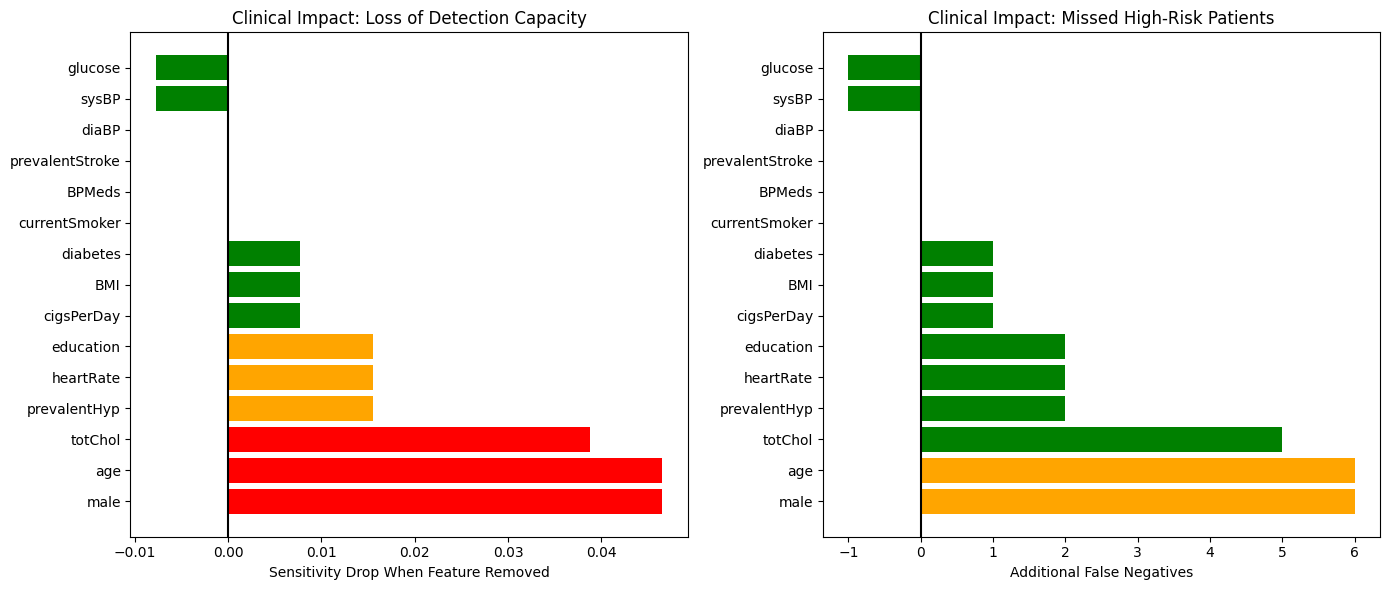

In [12]:
# 7. FEATURE SELECTION
# CLINICAL ABLATION STUDY (Sensitivity & False Negatives Focus)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("CLINICAL ABLATION STUDY (Sensitivity & False Negatives Focus)")

# Optimal threshold (from previous analysis)
optimal_threshold = 0.366

# Fixed best parameters
best_C = 1.0
best_penalty = 'l2'
best_class_weight = 'balanced'
best_solver = 'liblinear'

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train baseline model (all features)
baseline_model = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    class_weight=best_class_weight,
    solver=best_solver,
    random_state=42,
    max_iter=1000
)
baseline_model.fit(X_train_scaled, y_train)

# Baseline predictions
y_proba_base = baseline_model.predict_proba(X_test_scaled)[:, 1]
y_pred_base = (y_proba_base >= optimal_threshold).astype(int)

tn_base, fp_base, fn_base, tp_base = confusion_matrix(y_test, y_pred_base).ravel()
baseline_sensitivity = tp_base / (tp_base + fn_base)
baseline_false_negatives = fn_base
baseline_auc = roc_auc_score(y_test, y_proba_base)

print(f"Baseline (all features):")
print(f"  - AUC: {baseline_auc:.4f}")
print(f"  - Sensitivity: {baseline_sensitivity:.4f} ({tp_base}/{tp_base+fn_base})")
print(f"  - False Negatives: {fn_base}")
print("-" * 80)

# Get feature names
feature_names = X_train.columns.tolist()

# Ablation loop
ablation_results = []

for i, feature in enumerate(feature_names):
    # Remove current feature
    X_train_reduced = np.delete(X_train_scaled, i, axis=1)
    X_test_reduced = np.delete(X_test_scaled, i, axis=1)

    # Train model
    model = LogisticRegression(
        C=best_C,
        penalty=best_penalty,
        class_weight=best_class_weight,
        solver=best_solver,
        random_state=42,
        max_iter=1000
    )
    model.fit(X_train_reduced, y_train)

    # Predict
    y_proba = model.predict_proba(X_test_reduced)[:, 1]
    y_pred = (y_proba >= optimal_threshold).astype(int)

    # Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    sensitivity_drop = baseline_sensitivity - sensitivity
    fn_increase = fn - baseline_false_negatives

    ablation_results.append({
        'Feature': feature,
        'Sensitivity': sensitivity,
        'Sensitivity drop': sensitivity_drop,
        'False Negatives': fn,
        'FN increase': fn_increase
    })

    if sensitivity_drop > 0.05:
        impact = "HIGH"
    elif sensitivity_drop > 0.02:
        impact = "MODERATE"
    else:
        impact = "LOW"

    print(f"Removed '{feature}': Sens = {sensitivity:.4f} (drop = {sensitivity_drop:+.4f}) | FN = {fn} | Impact: {impact}")

# Results table
print("\n" + "=" * 70)
print("FEATURE IMPORTANCE RANKING (by Clinical Impact)")
print("=" * 70)

results_df = pd.DataFrame(ablation_results)
results_df = results_df.sort_values('Sensitivity drop', ascending=False)
print(results_df.to_string(index=False))

# Critical features
critical = results_df[results_df['Sensitivity drop'] > 0.03]['Feature'].tolist()
if critical:
    print(f"\nCRITICAL FEATURES (sensitivity drop >3%): {critical}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Sensitivity drop
colors = ['red' if d > 0.02 else 'orange' if d > 0.01 else 'green' for d in results_df['Sensitivity drop']]
ax1.barh(results_df['Feature'], results_df['Sensitivity drop'], color=colors)
ax1.axvline(x=0, color='black')
ax1.set_xlabel('Sensitivity Drop When Feature Removed')
ax1.set_title('Clinical Impact: Loss of Detection Capacity')

# FN increase
colors_fn = ['red' if inc > 10 else 'orange' if inc > 5 else 'green' for inc in results_df['FN increase']]
ax2.barh(results_df['Feature'], results_df['FN increase'], color=colors_fn)
ax2.axvline(x=0, color='black')
ax2.set_xlabel('Additional False Negatives')
ax2.set_title('Clinical Impact: Missed High-Risk Patients')

plt.tight_layout()
plt.show()

## Forward Feature Selection

Based on the ablation study results, a forward selection approach was implemented starting from the three most clinically relevant features (male, age, totChol). Features were added iteratively and evaluated based on their impact on sensitivity and false negatives.

Features that improved clinical performance will be kept. Neutral or degrading features will be  dropped.

In [13]:
# FORWARD FEATURE SELECTION (SIMPLIFIED)

feature_ranking = ['male', 'age', 'totChol', 'prevalentHyp', 'diabetes', 'education',
                   'diaBP', 'heartRate', 'BMI', 'glucose', 'sysBP', 'BPMeds',
                   'prevalentStroke', 'currentSmoker', 'cigsPerDay']

optimal_threshold = 0.366

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model template
def get_model():
    return LogisticRegression(C=1.0, penalty='l2', class_weight='balanced',
                              solver='liblinear', random_state=42, max_iter=1000)

# Evaluate function
def evaluate(features):
    idx = [feature_names.index(f) for f in features]
    model = get_model()
    model.fit(X_train_scaled[:, idx], y_train)
    y_proba = model.predict_proba(X_test_scaled[:, idx])[:, 1]
    y_pred = (y_proba >= optimal_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    return tp/(tp+fn), fn  # sensitivity, false_negatives

# Start with 3 features
current = ['male', 'age', 'totChol']
best_sens, best_fn = evaluate(current)
print(f"Baseline (3 features): Sens = {best_sens:.4f} | FN = {best_fn}")

# Add features one by one
for feature in feature_ranking[3:]:
    test_features = current + [feature]
    sens, fn = evaluate(test_features)

    if sens > best_sens or fn < best_fn:
        current = test_features
        best_sens, best_fn = sens, fn
        print(f"Added '{feature}': Sens = {sens:.4f} | FN = {fn} -> KEPT")
    else:
        print(f"Added '{feature}': Sens = {sens:.4f} | FN = {fn} -> DROPPED")

print("\n" + "=" * 50)
print(f"SELECTED MODEL: {len(current)} features")
print(f"Features: {current}")
print(f"Sensitivity: {best_sens:.4f}")
print(f"False Negatives: {best_fn}")

Baseline (3 features): Sens = 0.8217 | FN = 23
Added 'prevalentHyp': Sens = 0.8527 | FN = 19 -> KEPT
Added 'diabetes': Sens = 0.8450 | FN = 20 -> DROPPED
Added 'education': Sens = 0.8372 | FN = 21 -> DROPPED
Added 'diaBP': Sens = 0.8527 | FN = 19 -> DROPPED
Added 'heartRate': Sens = 0.8527 | FN = 19 -> DROPPED
Added 'BMI': Sens = 0.8450 | FN = 20 -> DROPPED
Added 'glucose': Sens = 0.8450 | FN = 20 -> DROPPED
Added 'sysBP': Sens = 0.8295 | FN = 22 -> DROPPED
Added 'BPMeds': Sens = 0.8527 | FN = 19 -> DROPPED
Added 'prevalentStroke': Sens = 0.8527 | FN = 19 -> DROPPED
Added 'currentSmoker': Sens = 0.8450 | FN = 20 -> DROPPED
Added 'cigsPerDay': Sens = 0.8605 | FN = 18 -> KEPT

SELECTED MODEL: 5 features
Features: ['male', 'age', 'totChol', 'prevalentHyp', 'cigsPerDay']
Sensitivity: 0.8605
False Negatives: 18


## Feature Selection Result

Forward feature selection identified an optimal subset of **5 features** that achieves comparable performance to the full 15-feature model:

| Model | Features | Sensitivity | False Negatives |
|-------|----------|-------------|-----------------|
| Full Model | 15 | 85.27% | 19 |
| **Selected Model** | **5** | **86.05%** | **18** |

### Selected Features
- `male` (sex)
- `age` (years)
- `totChol` (total cholesterol, mg/dL)
- `prevalentHyp` (prevalent hypertension)
- `cigsPerDay` (cigarettes per day)

### Clinical Interpretation

The selected model achieves slightly higher sensitivity (86.05% vs 85.27%) and fewer false negatives (18 vs 19) than the full model, while using only 5 variables. The ablation study confirms that `male`, `age`, and `totChol` are the most critical features (sensitivity drop >3% when removed).

This simplified model is:

- **More interpretable** for clinicians and patients
- **Less prone to overfitting** due to fewer parameters
- **Easier to deploy** in a Streamlit application

## Selected Model Evaluation (5 Features)

Based on the forward selection results, the final model is retrained using only the 5 most clinically relevant features: `male`, `age`, `totChol`, `prevalentHyp`, and `cigsPerDay`.

The model is evaluated on the test set using the optimal threshold (0.366) optimized for sensitivity.
## 7.1 Train and Evaluate Selected Model

The model is retrained using only the 5 selected features, the confusion matrix and ROC curve are displayed below and a new scaler (`scaler5`) is fitted on these features to avoid dependency on the original 15 variables.


SELECTED MODEL PERFORMANCE (5 FEATURES)
ROC-AUC: 0.6922
Sensitivity: 0.8605 (111/129)
Specificity: 0.4506 (324/719)
False Positives: 395
False Negatives: 18


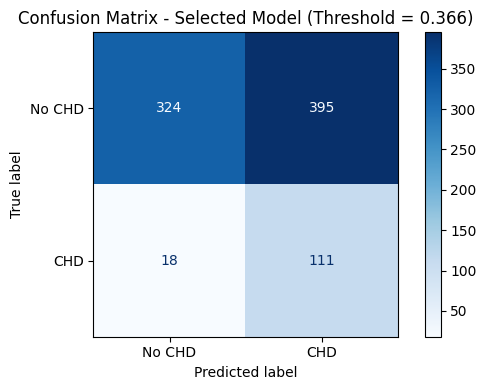

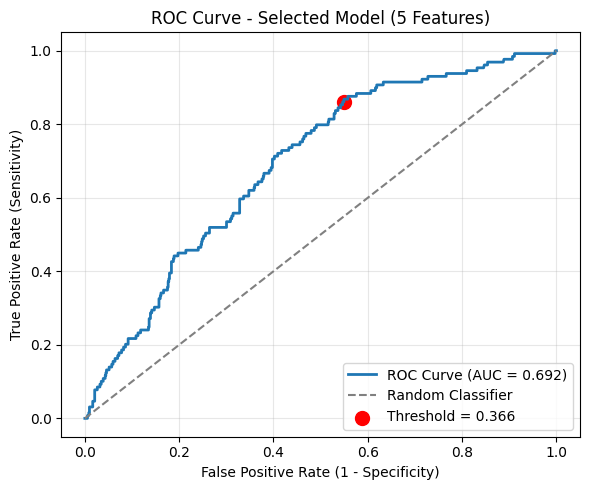

['scaler5.pkl']

In [14]:
# 7.1 TRAIN AND EVALUATE SELECTED MODEL (5 FEATURES)

# Use raw (unscaled) data
X_train_raw = X_train.values
X_test_raw = X_test.values

# Select only the 5 features
selected_features = ['male', 'age', 'totChol', 'prevalentHyp', 'cigsPerDay']
selected_indices = [feature_names.index(f) for f in selected_features]

X_train_5 = X_train_raw[:, selected_indices]
X_test_5 = X_test_raw[:, selected_indices]

# Fit a new scaler on the 5 features (no dependency on other variables)
scaler5 = StandardScaler()
X_train_5_scaled = scaler5.fit_transform(X_train_5)
X_test_5_scaled = scaler5.transform(X_test_5)

# Train final model
final_model = LogisticRegression(
    C=1.0,
    penalty='l2',
    class_weight='balanced',
    solver='liblinear',
    random_state=42,
    max_iter=1000
)
final_model.fit(X_train_5_scaled, y_train)

# Predictions
y_proba = final_model.predict_proba(X_test_5_scaled)[:, 1]
optimal_threshold = 0.366
y_pred = (y_proba >= optimal_threshold).astype(int)

# Metrics
test_auc = roc_auc_score(y_test, y_proba)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("=" * 60)
print("SELECTED MODEL PERFORMANCE (5 FEATURES)")
print("=" * 60)
print(f"ROC-AUC: {test_auc:.4f}")
print(f"Sensitivity: {sensitivity:.4f} ({tp}/{tp+fn})")
print(f"Specificity: {specificity:.4f} ({tn}/{tn+fp})")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No CHD", "CHD"], ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix - Selected Model (Threshold = {optimal_threshold:.3f})")
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.scatter(1 - specificity, sensitivity, color="red", s=100, label=f"Threshold = {optimal_threshold:.3f}")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - Selected Model (5 Features)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the scaler for deployment
import joblib
joblib.dump(scaler5, 'scaler5.pkl')


## 8. MODEL CALIBRATION

Calibration adjusts predicted probabilities so they reflect true event frequencies. For example, a calibrated model predicting 30% risk should have approximately 30% of those patients actually developing CHD.

Our model currently outputs uncalibrated probabilities. We apply Platt scaling (sigmoid calibration) to improve probability accuracy.

In [15]:
# 8. MODEL CALIBRATION

from sklearn.calibration import CalibratedClassifierCV

# Calibrate selected model using Platt scaling

# Train calibrated model
calibrated_model = CalibratedClassifierCV(final_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_5_scaled, y_train)

# Get calibrated probabilities
y_proba_calibrated = calibrated_model.predict_proba(X_test_5_scaled)[:, 1]

# Apply same threshold
y_pred_calibrated = (y_proba_calibrated >= optimal_threshold).astype(int)

# Quick comparison
print("Before calibration:")
print(f"  - Min prob: {y_proba.min():.4f}, Max prob: {y_proba.max():.4f}")
print("After calibration:")
print(f"  - Min prob: {y_proba_calibrated.min():.4f}, Max prob: {y_proba_calibrated.max():.4f}")

Before calibration:
  - Min prob: 0.1008, Max prob: 0.9127
After calibration:
  - Min prob: 0.0229, Max prob: 0.6273


## 9. SHAP Analysis (Model Explainability)

SHAP (SHapley Additive exPlanations) explains how each feature contributes to the model's prediction for an individual patient.

- **Positive SHAP value** = feature increases CHD risk
- **Negative SHAP value** = feature decreases CHD risk

The summary plot shows which features most influence predictions globally. Force plots can be generated for individual patients to provide personalized explanations in the Streamlit app.

/usr/local/lib/python3.12/dist-packages/shap/explainers/_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


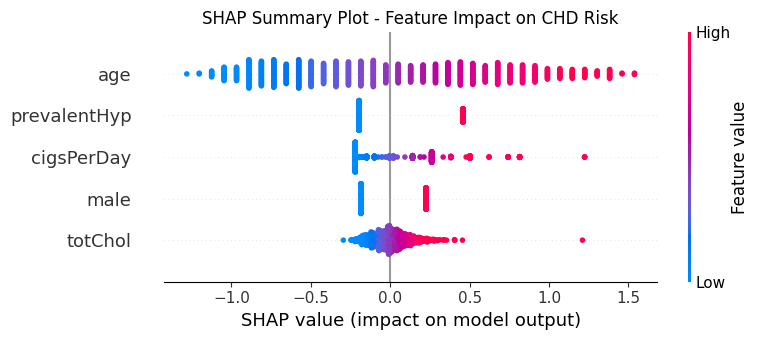

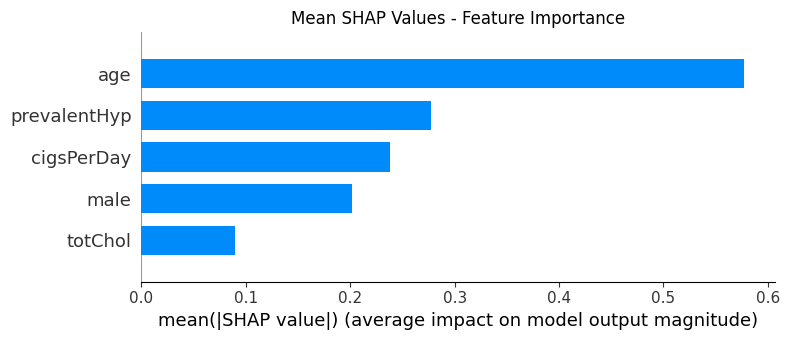

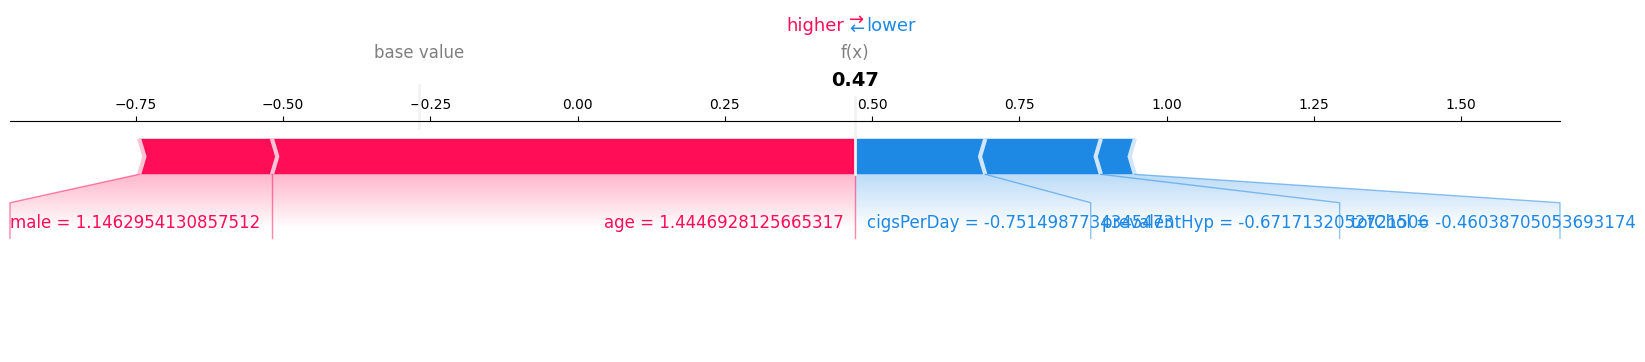

In [16]:
# 9. SHAP ANALYSIS - MODEL EXPLAINABILITY
import shap

# SHAP explainer for Logistic Regression
explainer = shap.LinearExplainer(
    final_model,
    X_train_5_scaled,
    feature_perturbation='interventional'
)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_5_scaled)

# Summary plot (global feature importance)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_5_scaled, feature_names=selected_features, show=False)
plt.title('SHAP Summary Plot - Feature Impact on CHD Risk')
plt.tight_layout()
plt.show()

# Bar plot (mean absolute SHAP values)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test_5_scaled, feature_names=selected_features, plot_type="bar", show=False)
plt.title('Mean SHAP Values - Feature Importance')
plt.tight_layout()
plt.show()

# Example: Force plot for first test patient
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0, :], X_test_5_scaled[0, :],
                feature_names=selected_features, matplotlib=True)

## Model Validation Test

Before deploying the model, we verify that it produces plausible risk estimates. A typical patient profile (male, 50 years, total cholesterol 200 mg/dL, hypertensive, 10 cigarettes/day) is tested:

In [17]:
# Test data (typical values for a patient)
# Order: male, age, totChol, prevalentHyp, cigsPerDay
test_raw = np.array([[1, 50, 200, 1, 10]])

# Scale
test_scaled = scaler5.transform(test_raw)

# Predict using the final_model (trained on 5 features)
risk = final_model.predict_proba(test_scaled)[0][1]
print(f"Risk: {risk:.4f}")   # It should give something like 0.3–0.6, not 1.0

Risk: 0.5948


## 10. SAVING THE MODEL

The final model (5 features) is saved as `best_model.pkl`, along with feature names and deployment parameters (threshold, sensitivity). These files will be used in the Streamlit application.

In [18]:
# 10. SAVING THE MODEL

import json # Import json

drive.mount("/content/drive", force_remount=True)

# The 'final_model' and 'scaler5' are already available from previous cells.
# No need to re-train the model or re-scale the data here.

path = '/content/drive/MyDrive/framingham_plus_notebooks/'
joblib.dump(final_model, path + 'best_model.pkl') # Save the already trained final_model
joblib.dump(scaler5, path + 'scaler5.pkl')         # Save the associated scaler

selected_features_for_json = ['male', 'age', 'totChol', 'prevalentHyp', 'cigsPerDay']

with open(path + 'feature_names.json', 'w') as f:
    json.dump(selected_features_for_json, f)
with open(path + 'deployment_info.json', 'w') as f:
    json.dump({'threshold': 0.366, 'sensitivity': 0.8605, 'false_negatives': 18, 'features': selected_features_for_json}, f)

print(f"Model saved to: {path + 'best_model.pkl'}")
print(f"Scaler saved to: {path + 'scaler5.pkl'}")
print(f"Feature names saved to: {path + 'feature_names.json'}")
print(f"Deployment info saved to: {path + 'deployment_info.json'}")

Mounted at /content/drive
Model saved to: /content/drive/MyDrive/framingham_plus_notebooks/best_model.pkl
Scaler saved to: /content/drive/MyDrive/framingham_plus_notebooks/scaler5.pkl
Feature names saved to: /content/drive/MyDrive/framingham_plus_notebooks/feature_names.json
Deployment info saved to: /content/drive/MyDrive/framingham_plus_notebooks/deployment_info.json
